Best model for each task (by Test AUC):


,task,label,model,roc_auc,f1,accuracy,precision,recall
0,after_mask,After mandate - Face mask,xgboost,0.8867,0.8859,0.8402,0.8944,0.8775
1,after_protective,After mandate - Protective behaviour,xgboost,0.8461,0.8314,0.7702,0.8866,0.7826
2,before_mask,Before mandate - Face mask,xgboost,0.8502,0.6228,0.7815,0.5620,0.6982
3,before_protective,Before mandate - Protective behaviour,xgboost,0.7925,0.7245,0.7079,0.7234,0.7257


Overall TEST mean performance:


,model,roc_auc,f1,accuracy,precision,recall
2,xgboost,0.8439,0.7661,0.7750,0.7666,0.7710
1,random_forest,0.8314,0.7585,0.7652,0.7584,0.7660
0,classification_tree,0.7996,0.7356,0.7401,0.7375,0.7477


Overall CV mean performance:


,model,roc_auc,f1,accuracy,precision,recall
2,xgboost,0.8447,0.7715,0.7789,0.7726,0.7766
1,random_forest,0.8329,0.7612,0.7673,0.7609,0.7692
0,classification_tree,0.7952,0.7341,0.7368,0.7364,0.7481


Final model comparison table:


,model,roc_auc_test,f1_test,accuracy_test,precision_test,recall_test,roc_auc_cv,f1_cv,accuracy_cv,precision_cv,recall_cv
0,xgboost,0.8439,0.7661,0.7750,0.7666,0.7710,0.8447,0.7715,0.7789,0.7726,0.7766
1,random_forest,0.8314,0.7585,0.7652,0.7584,0.7660,0.8329,0.7612,0.7673,0.7609,0.7692
2,classification_tree,0.7996,0.7356,0.7401,0.7375,0.7477,0.7952,0.7341,0.7368,0.7364,0.7481


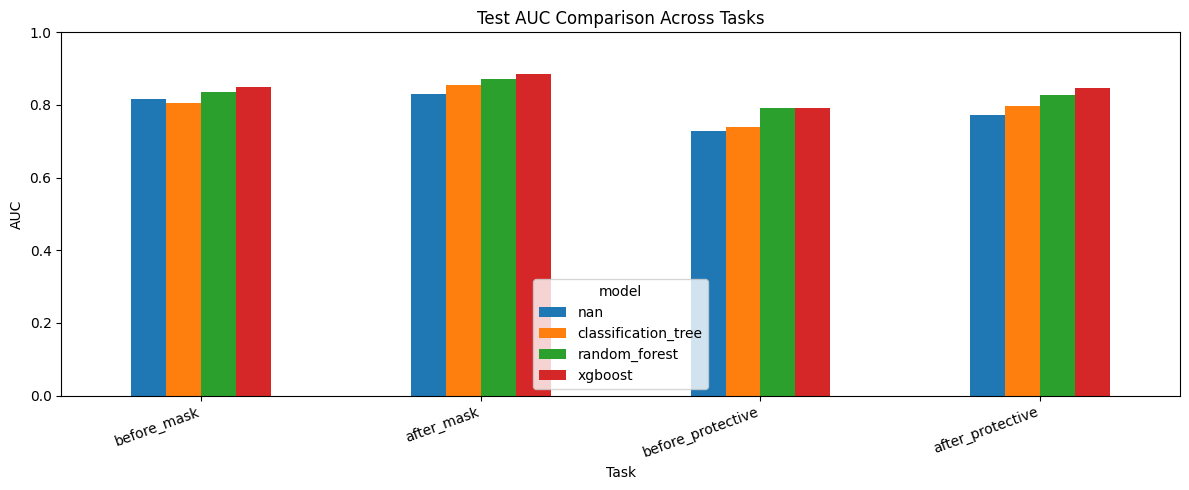

Overall best model by mean Test AUC: xgboost (0.8439)


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("../data/model_results")

cv_files = [
    OUTPUT_DIR / "logistic_regression_cv_summary.csv",
    OUTPUT_DIR / "classification_tree_cv_summary.csv",
    OUTPUT_DIR / "xgboost_cv_summary.csv",
    OUTPUT_DIR / "random_forest_cv_summary.csv",
]

test_files = [
    OUTPUT_DIR / "logistic_regression_test_summary.csv",
    OUTPUT_DIR / "classification_tree_test_summary.csv",
    OUTPUT_DIR / "xgboost_test_summary.csv",
    OUTPUT_DIR / "random_forest_test_summary.csv",
]

cv_df = pd.concat([pd.read_csv(f) for f in cv_files], ignore_index=True)
test_df = pd.concat([pd.read_csv(f) for f in test_files], ignore_index=True)

metric_order = ["roc_auc", "f1", "accuracy", "precision", "recall"]
task_order = ["before_mask", "after_mask", "before_protective", "after_protective"]

# 1) 每个任务上，按测试集 AUC 选最佳模型
best_by_task = (
    test_df.sort_values(["task", "roc_auc"], ascending=[True, False])
    .groupby("task", as_index=False)
    .head(1)
    .loc[:, ["task", "label", "model"] + metric_order]
    .reset_index(drop=True)
)

print("Best model for each task (by Test AUC):")
display(best_by_task.round(4))

# 2) 整体平均表现
overall_test = (
    test_df.groupby("model", as_index=False)[metric_order]
    .mean()
    .sort_values("roc_auc", ascending=False)
)

overall_cv = (
    cv_df.groupby("model", as_index=False)[metric_order]
    .mean()
    .sort_values("roc_auc", ascending=False)
)

print("Overall TEST mean performance:")
display(overall_test.round(4))

print("Overall CV mean performance:")
display(overall_cv.round(4))

# 3) 合并成一张总表
comparison_table = overall_test.merge(
    overall_cv,
    on="model",
    suffixes=("_test", "_cv")
)

comparison_table = comparison_table[
    [
        "model",
        "roc_auc_test", "f1_test", "accuracy_test", "precision_test", "recall_test",
        "roc_auc_cv", "f1_cv", "accuracy_cv", "precision_cv", "recall_cv"
    ]
].sort_values("roc_auc_test", ascending=False)

print("Final model comparison table:")
display(comparison_table.round(4))

# 4) 可视化：按任务比较 Test AUC
pivot_auc = test_df.pivot(index="task", columns="model", values="roc_auc").loc[task_order]

ax = pivot_auc.plot(kind="bar", figsize=(12, 5))
ax.set_title("Test AUC Comparison Across Tasks")
ax.set_xlabel("Task")
ax.set_ylabel("AUC")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# 5) 给出结论
best_overall_model = comparison_table.iloc[0]["model"]
best_overall_auc = comparison_table.iloc[0]["roc_auc_test"]

print(f"Overall best model by mean Test AUC: {best_overall_model} ({best_overall_auc:.4f})")


## Before mandate - Face mask

## After mandate - Face mask

## Before mandate - Protective behaviour

## After mandate - Protective behaviour

## Full comparison table

...

,task,label,model,roc_auc,f1,precision,recall,accuracy,best_cv_auc
0,after_mask,After mandate - Face mask,xgboost,0.8923,0.8951,0.8911,0.8992,0.8512,0.8926
1,after_protective,After mandate - Protective behaviour,xgboost,0.8493,0.8485,0.8748,0.8237,0.7871,0.8516
2,before_mask,Before mandate - Face mask,xgboost,0.8461,0.6141,0.5625,0.6762,0.7805,0.8606
3,before_protective,Before mandate - Protective behaviour,random_forest,0.7963,0.7404,0.7260,0.7554,0.7196,0.7791


## AUC pivot

task,after_mask,after_protective,before_mask,before_protective
model,,,,
classification_tree,0.8546,0.8000,0.8005,0.7435
logistic_regression,0.8302,0.7736,0.8151,0.7292
random_forest,0.8895,0.8415,0.8407,0.7963
xgboost,0.8923,0.8493,0.8461,0.7920


## F1 pivot

task,after_mask,after_protective,before_mask,before_protective
model,,,,
classification_tree,0.8726,0.8048,0.5794,0.6970
logistic_regression,0.8203,0.7907,0.5804,0.6855
random_forest,0.8950,0.8542,0.6078,0.7404
xgboost,0.8951,0.8485,0.6141,0.7311


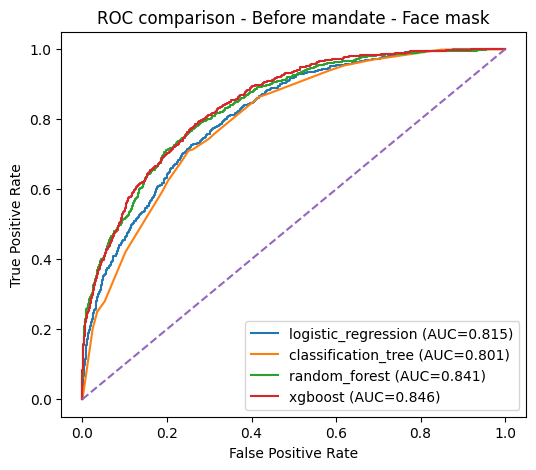

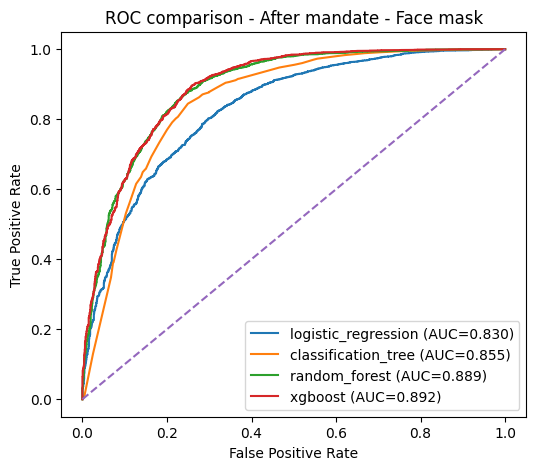

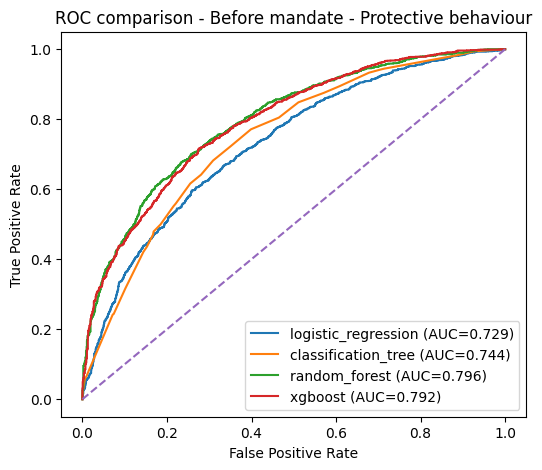

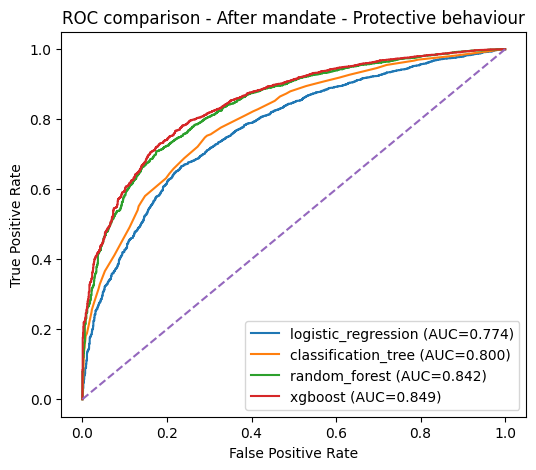

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score,
    accuracy_score,
    f1_score,
    roc_curve,
)

DATA_DIR = Path("../data/paper_final_splits")

RANDOM_STATE = 20240627
N_SPLITS = 5
N_ITER_TREE = 40
N_ITER_RF = 40
N_ITER_XGB = 40

TASKS = {
    "before_mask": "Before mandate - Face mask",
    "after_mask": "After mandate - Face mask",
    "before_protective": "Before mandate - Protective behaviour",
    "after_protective": "After mandate - Protective behaviour",
}

METRICS = ["precision", "recall", "roc_auc", "accuracy", "f1"]


def load_task(task):
    X_train = pd.read_csv(DATA_DIR / f"X_train_{task}.csv")
    X_test = pd.read_csv(DATA_DIR / f"X_test_{task}.csv")
    y_train = pd.read_csv(DATA_DIR / f"y_train_{task}.csv").iloc[:, 0].astype(int)
    y_test = pd.read_csv(DATA_DIR / f"y_test_{task}.csv").iloc[:, 0].astype(int)
    return X_train, X_test, y_train, y_test


def upsample(X, y, seed):
    ros = RandomOverSampler(random_state=seed)
    X_up, y_up = ros.fit_resample(X, y)
    return X_up, pd.Series(y_up, name="target")


def get_metrics(y_true, y_pred, y_prob):
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


def run_logistic(X_train, X_test, y_train, y_test):
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    cv_rows = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        X_tr_up, y_tr_up = upsample(X_tr, y_tr, RANDOM_STATE + fold)

        model = LogisticRegression(
            max_iter=5000,
            solver="liblinear",
            random_state=RANDOM_STATE
        )
        model.fit(X_tr_up, y_tr_up)

        y_val_pred = model.predict(X_val)
        y_val_prob = model.predict_proba(X_val)[:, 1]

        row = get_metrics(y_val, y_val_pred, y_val_prob)
        row["fold"] = fold
        cv_rows.append(row)

    cv_df = pd.DataFrame(cv_rows)

    X_train_up, y_train_up = upsample(X_train, y_train, RANDOM_STATE)
    final_model = LogisticRegression(
        max_iter=5000,
        solver="liblinear",
        random_state=RANDOM_STATE
    )
    final_model.fit(X_train_up, y_train_up)

    y_test_pred = final_model.predict(X_test)
    y_test_prob = final_model.predict_proba(X_test)[:, 1]

    return {
        "best_params": {},
        "best_cv_auc": cv_df["roc_auc"].mean(),
        "test_metrics": get_metrics(y_test, y_test_pred, y_test_prob),
        "y_test_prob": y_test_prob,
        "y_test": y_test,
    }


def run_tree_search(X_train, X_test, y_train, y_test):
    pipe = Pipeline(steps=[
        ("ros", RandomOverSampler(random_state=RANDOM_STATE)),
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ])

    param_distributions = {
        "model__criterion": ["gini", "entropy"],
        "model__max_depth": [3, 5, 8, 10, 12, 15, 20, None],
        "model__min_samples_split": [2, 5, 10, 20, 30, 50],
        "model__min_samples_leaf": [1, 2, 5, 10, 20],
        "model__min_impurity_decrease": [0.0, 0.0001, 0.001, 0.005, 0.01],
    }

    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions,
        n_iter=N_ITER_TREE,
        scoring="roc_auc",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=1,
        refit=True,
        verbose=0,
    )
    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    y_test_pred = best_model.predict(X_test)
    y_test_prob = best_model.predict_proba(X_test)[:, 1]

    return {
        "best_params": search.best_params_,
        "best_cv_auc": search.best_score_,
        "test_metrics": get_metrics(y_test, y_test_pred, y_test_prob),
        "y_test_prob": y_test_prob,
        "y_test": y_test,
    }


def run_rf_search(X_train, X_test, y_train, y_test):
    pipe = Pipeline(steps=[
        ("ros", RandomOverSampler(random_state=RANDOM_STATE)),
        ("model", RandomForestClassifier(
            n_estimators=250,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

    param_distributions = {
        "model__max_depth": [5, 8, 10, 12, 15, 20, None],
        "model__min_samples_split": [2, 5, 10, 20, 30],
        "model__min_samples_leaf": [1, 2, 5, 10],
        "model__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7, None],
        "model__bootstrap": [True],
    }

    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions,
        n_iter=N_ITER_RF,
        scoring="roc_auc",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=1,
        refit=True,
        verbose=0,
    )
    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    y_test_pred = best_model.predict(X_test)
    y_test_prob = best_model.predict_proba(X_test)[:, 1]

    return {
        "best_params": search.best_params_,
        "best_cv_auc": search.best_score_,
        "test_metrics": get_metrics(y_test, y_test_pred, y_test_prob),
        "y_test_prob": y_test_prob,
        "y_test": y_test,
    }


def run_xgb_search(X_train, X_test, y_train, y_test):
    pipe = Pipeline(steps=[
        ("ros", RandomOverSampler(random_state=RANDOM_STATE)),
        ("model", XGBClassifier(
            n_estimators=250,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist"
        ))
    ])

    param_distributions = {
        "model__max_depth": [3, 4, 5, 6, 8, 10],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
        "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
        "model__colsample_bytree": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        "model__min_child_weight": [1, 3, 5, 7],
        "model__gamma": [0, 0.01, 0.1, 0.3, 0.5, 1.0],
        "model__reg_alpha": [0, 0.01, 0.1, 1.0],
        "model__reg_lambda": [0.5, 1.0, 2.0, 5.0],
    }

    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions,
        n_iter=N_ITER_XGB,
        scoring="roc_auc",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=1,
        refit=True,
        verbose=0,
    )
    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    y_test_pred = best_model.predict(X_test)
    y_test_prob = best_model.predict_proba(X_test)[:, 1]

    return {
        "best_params": search.best_params_,
        "best_cv_auc": search.best_score_,
        "test_metrics": get_metrics(y_test, y_test_pred, y_test_prob),
        "y_test_prob": y_test_prob,
        "y_test": y_test,
    }


runner_map = {
    "logistic_regression": run_logistic,
    "classification_tree": run_tree_search,
    "random_forest": run_rf_search,
    "xgboost": run_xgb_search,
}

all_rows = []
roc_store = {}

for task, label in TASKS.items():
    X_train, X_test, y_train, y_test = load_task(task)

    display(Markdown(f"## {label}"))

    for model_name, runner in runner_map.items():
        out = runner(X_train, X_test, y_train, y_test)

        row = {
            "model": model_name,
            "task": task,
            "label": label,
            "best_cv_auc": out["best_cv_auc"],
            **out["test_metrics"],
            "best_params": str(out["best_params"]),
        }
        all_rows.append(row)

        roc_store[(task, model_name)] = {
            "y_test": out["y_test"],
            "y_prob": out["y_test_prob"],
        }

comparison_df = pd.DataFrame(all_rows)
comparison_df = comparison_df.sort_values(["task", "roc_auc"], ascending=[True, False])

display(Markdown("## Full comparison table"))
display(comparison_df.round(4))

display(Markdown("## Best model per task by test AUC"))
best_df = comparison_df.groupby("task", as_index=False).first()
display(best_df[["task", "label", "model", "roc_auc", "f1", "precision", "recall", "accuracy", "best_cv_auc"]].round(4))

display(Markdown("## AUC pivot"))
auc_pivot = comparison_df.pivot(index="model", columns="task", values="roc_auc")
display(auc_pivot.round(4))

display(Markdown("## F1 pivot"))
f1_pivot = comparison_df.pivot(index="model", columns="task", values="f1")
display(f1_pivot.round(4))

for task, label in TASKS.items():
    plt.figure(figsize=(6, 5))
    for model_name in runner_map.keys():
        y_true = roc_store[(task, model_name)]["y_test"]
        y_prob = roc_store[(task, model_name)]["y_prob"]
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc_value = roc_auc_score(y_true, y_prob)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_value:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC comparison - {label}")
    plt.legend()
    plt.show()
